In [3]:
import json
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt
C2A_PALETTE = {
    "primary" : "#2E86AB", # Steel Blue — main model / baseline
    "secondary" : "#A23B72", # Raspberry — comparison model
    "tertiary" : "#F18F01", # Amber — third model / ablation
    "neutral" : "#6C757D", # Slate Gray — reference lines, grids
    "success" : "#3BB273", # Emerald — positive results
    "warning" : "#E84855", # Crimson — failure / error cases
    "bg" : "#F8F9FA", # Off-White — figure background
    "text" : "#212529", # Near-Black — labels, titles
}

In [4]:
def setup_style():
    """Apply the canonical Click2Act style to matplotlib."""
    plt.rcParams.update({
        "figure.facecolor": C2A_PALETTE["bg"],
        "axes.facecolor": C2A_PALETTE["bg"],
        "text.color": C2A_PALETTE["text"],
        "axes.labelcolor": C2A_PALETTE["text"],
        "xtick.color": C2A_PALETTE["text"],
        "ytick.color": C2A_PALETTE["text"],
        "axes.edgecolor": C2A_PALETTE["neutral"],
        "grid.color": C2A_PALETTE["neutral"],
        "grid.alpha": 0.3,
        "font.family": "sans-serif"
    })
    sns.set_style("whitegrid", {
        "axes.facecolor": C2A_PALETTE["bg"],
        "figure.facecolor": C2A_PALETTE["bg"],
        "grid.color": C2A_PALETTE["neutral"]
    })
def save_figure(fig, filename):
    """Save a figure as PDF in the paper/figs directory."""
    out_dir = Path("paper/figs")
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / f"{filename}.pdf"
    fig.savefig(out_path, format="pdf", bbox_inches="tight", facecolor=fig.get_facecolor())
    print(f"Saved {out_path}")

## Text Degradation

In [5]:
pth = Path("../experiments/2026-05-9_text-degradation-task/metrics.json")
text_degradtion_results = json.loads(pth.read_text())

In [11]:
text_degradtion_results
# text_degradtion_results['levels'][0]['noise_level'] = 0

{'experiment': 'experiments/2026-05-9_text-degradation-task',
 'baseline': 'text_degradation_L0.jsonl',
 'mode': 'output stability (direct)',
 'levels': [{'file': 'text_degradation_L0.jsonl',
   'noise_level': 0,
   'n_entries': 13258,
   'mean_miou': 1.0,
   'sensitivity_index': 0.0},
  {'file': 'text_degradation_L1.jsonl',
   'noise_level': 1,
   'n_entries': 8048,
   'skipped_no_base': 5210,
   'mean_miou': 0.323449,
   'sensitivity_index': -0.676551},
  {'file': 'text_degradation_L2.jsonl',
   'noise_level': 2,
   'n_entries': 8048,
   'skipped_no_base': 5210,
   'mean_miou': 0.148011,
   'sensitivity_index': -0.425994},
  {'file': 'text_degradation_L3.jsonl',
   'noise_level': 3,
   'n_entries': 8048,
   'skipped_no_base': 5210,
   'mean_miou': 0.074289,
   'sensitivity_index': -0.30857}]}

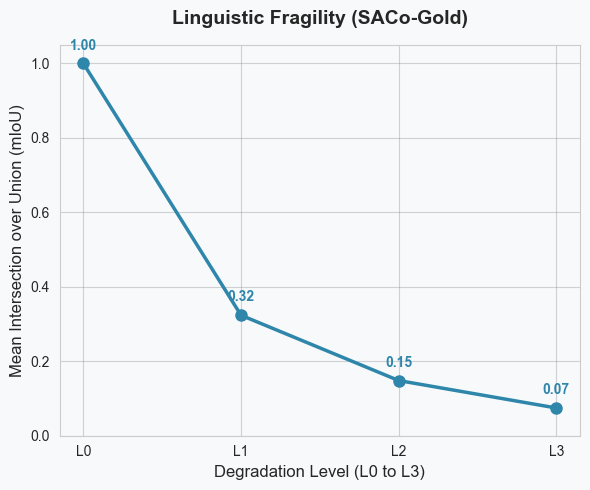

In [12]:
def plot_text_degradation(results_dict):
    """Plot the robustness curve for Text Degradation."""
    setup_style()
    fig, ax = plt.subplots(figsize=(6, 5))
    
    # Extract data, handling the "people" bug if it hasn't been fixed in the dict yet
    levels = [lvl['noise_level'] for lvl in results_dict['levels']]
    mious = [lvl['mean_miou'] for lvl in results_dict['levels']]

        
    ax.plot(levels, mious, marker='o', color=C2A_PALETTE["primary"], linewidth=2.5, markersize=8)
    
    # Styling
    ax.set_title("Linguistic Fragility (SACo-Gold)", fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel("Degradation Level (L0 to L3)", fontsize=12)
    ax.set_ylabel("Mean Intersection over Union (mIoU)", fontsize=12)
    ax.set_ylim(0, 1.05)
    ax.set_xticks(levels)
    ax.set_xticklabels([f"L{lvl}" for lvl in levels])
    
    # Add value annotations on the points
    for x, y in zip(levels, mious):
        ax.annotate(f"{y:.2f}", 
                    (x, y), 
                    textcoords="offset points", 
                    xytext=(0, 10), 
                    ha='center',
                    fontsize=10,
                    fontweight='bold',
                    color=C2A_PALETTE["primary"])
    
    plt.tight_layout()
    # save_figure(fig, "fig?1_text_degradation")
    plt.show()

plot_text_degradation(text_degradtion_results)

## Visual Degradation

In [14]:
visual_degradation_1_pth = Path("../experiments/2026-05-15_visual-degradation-task/metrics.json")
visual_degradation_1 = json.loads(visual_degradation_1_pth.read_text())

In [16]:
visual_degradation_1_data = {lvl['sigma']:lvl['mean_miou']  for lvl in visual_degradation_1['levels']}
visual_degradation_1_data

{0: 1.0, 10: 0.758296, 25: 0.660726, 50: 0.588392}

In [ ]:
visual_degradation_flip_pth = Path("../experiments/2026-5-16_visual-degradation-flip-task/metrics.json")
visual_degradation_flip = json.loads(visual_degradation_flip_pth.read_text())

## All

In [ ]:
text_deg_pth = Path("../experiments/2026-05-9_text-degradation-task/metrics.json")
sa1b_noise_pth = Path("../experiments/2026-05-15_visual-degradation-task/metrics.json")
saco_noise_pth = Path("../experiments/2026-05-16_visual-degradation-task-SACo/metrics.json")

text_deg_data = json.loads(text_deg_pth.read_text())
sa1b_noise_data = json.loads(sa1b_noise_pth.read_text())
saco_noise_data = json.loads(saco_noise_pth.read_text())
# small fix
text_deg_data['levels'][0]['noise_level'] = 0
saco_noise_data['levels'][0]['noise_level'] = 0


text_metrics = {lvl['noise_level']:lvl['mean_miou']  for lvl in text_deg_data['levels']}
sa1b_noise = {lvl['sigma']:lvl['mean_miou']  for lvl in sa1b_noise_data['levels']}
saco_noise  = {lvl['noise_level']:lvl['mean_miou']  for lvl in saco_noise_data['levels']}

In [ ]:
plot_robustness_curves(text_metrics, sa1b_noise, saco_noise)

{'experiment': 'experiments/2026-05-16_visual-degradation-task-SACo',
 'baseline': 'visual_degradation_L0.jsonl',
 'mode': 'output stability (direct)',
 'levels': [{'file': 'visual_degradation_L0.jsonl',
   'noise_level': 'people',
   'n_entries': 13258,
   'mean_miou': 1.0,
   'sensitivity_index': 0.0},
  {'file': 'visual_degradation_L10.jsonl',
   'noise_level': 10,
   'n_entries': 8048,
   'skipped_no_base': 5210,
   'mean_miou': 0.923213,
   'sensitivity_index': -0.007679},
  {'file': 'visual_degradation_L25.jsonl',
   'noise_level': 25,
   'n_entries': 8048,
   'skipped_no_base': 5210,
   'mean_miou': 0.868694,
   'sensitivity_index': -0.005252},
  {'file': 'visual_degradation_L50.jsonl',
   'noise_level': 50,
   'n_entries': 8048,
   'skipped_no_base': 5210,
   'mean_miou': 0.812695,
   'sensitivity_index': -0.003746}]}

In [13]:

def plot_robustness_curves(text_metrics, sa1b_noise, saco_noise):
    """Fig 1: Robustness curves for Text Degradation and Gaussian Noise."""
    setup_style()
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Panel 1: Text Degradation
    levels = list(text_metrics.keys())
    mious = list(text_metrics.values())
    
    ax1.plot(levels, mious, marker='o', color=C2A_PALETTE["primary"], linewidth=2, markersize=8)
    ax1.set_title("Linguistic Fragility (SACo-Gold)", fontsize=14, fontweight='bold')
    ax1.set_xlabel("Degradation Level", fontsize=12)
    ax1.set_ylabel("mIoU", fontsize=12)
    ax1.set_ylim(0, 1.05)
    
    # Panel 2: Gaussian Noise
    sigmas = list(sa1b_noise.keys())
    sa1b_mious = list(sa1b_noise.values())
    saco_mious = list(saco_noise.values())
    
    ax2.plot(sigmas, saco_mious, marker='s', color=C2A_PALETTE["primary"], 
             linewidth=2, markersize=8, label="Text Prompts (SACo-Gold)")
    ax2.plot(sigmas, sa1b_mious, marker='^', color=C2A_PALETTE["secondary"], 
             linewidth=2, markersize=8, label="Point Prompts (SA-1B)")
    ax2.set_title("Visual Noise Robustness", fontsize=14, fontweight='bold')
    ax2.set_xlabel("Gaussian Noise (σ)", fontsize=12)
    ax2.set_ylabel("mIoU", fontsize=12)
    ax2.set_ylim(0, 1.05)
    ax2.legend(fontsize=11)
    
    plt.tight_layout()
    save_figure(fig, "fig1_robustness_curves")
    plt.close(fig)